In [2]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
filename = "data/preprocessed_combined_om.xlsx" # removed an outlier row which had value ~20 for om

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)

spectral_data = df.iloc[:, 3:436]
output_variable = df.iloc[:, 438:439]


In [4]:
spectral_data.head()
output_variable.head()

,OM
0,1.8
1,0.4
2,0.2
3,1.9
4,2.0


In [5]:
print(spectral_data.shape)
print(output_variable.shape)

(150, 433)
(150, 1)


In [6]:
output_variable.describe()

,OM
count,150.000000
mean,1.500000
std,1.054298
min,0.200000
25%,0.800000
50%,1.200000
75%,1.900000
max,7.900000


Text(0.5, 1.0, 'Output OM Distribution')

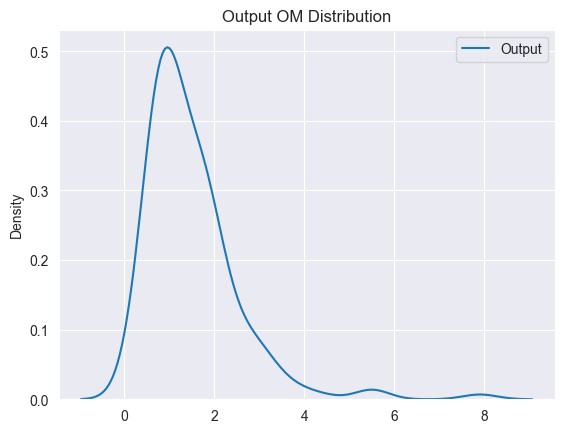

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output OM Distribution")

In [9]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

<Axes: ylabel='Density'>

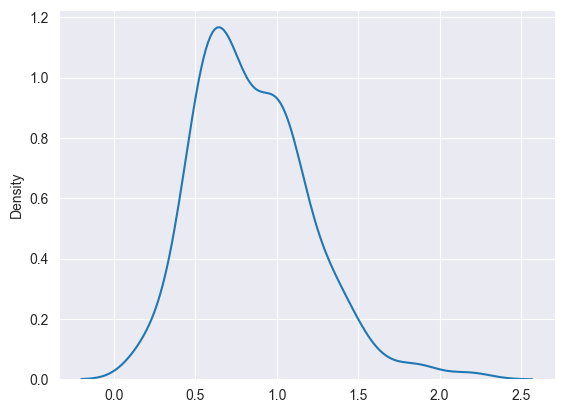

In [45]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

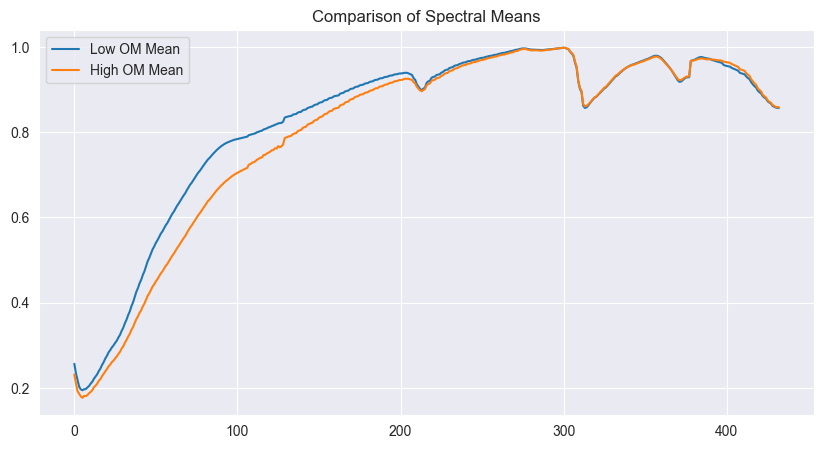

In [10]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low OM Mean')
plt.plot(np.mean(high_n, axis=0), label='High OM Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feat_select', SelectKBest(score_func=f_regression, k=50)),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)


# pipeline = Pipeline([
#     ('snv', SNV()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [23]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [24]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.1683
LOOCV RMSE: 0.9583


Train/Test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [26]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
22,0.207057,0.201176,0.181745,0.164542,0.168972,0.158532,0.164931,0.164309,0.165216,0.165786,...,0.885331,0.882775,0.877075,0.875175,0.870615,0.863534,0.869130,0.854932,0.850925,0.860252
15,0.361333,0.235588,0.205330,0.252762,0.213328,0.206740,0.236767,0.214160,0.221927,0.240118,...,0.932674,0.924815,0.927958,0.922103,0.919514,0.914644,0.913165,0.914428,0.914428,0.911994
65,0.294486,0.248949,0.232765,0.218048,0.205236,0.206664,0.211583,0.205514,0.215351,0.219119,...,0.776570,0.772022,0.763083,0.757530,0.755785,0.747322,0.743462,0.739072,0.737697,0.737961
11,0.311849,0.219691,0.209301,0.232581,0.195688,0.199022,0.216524,0.203912,0.209746,0.221830,...,0.877542,0.873949,0.873393,0.867874,0.860651,0.861022,0.852021,0.859836,0.855873,0.854243
42,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.925727,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058
106,0.182750,0.164332,0.159684,0.145615,0.143632,0.143384,0.143694,0.144376,0.148280,0.149427,...,0.886561,0.883752,0.873546,0.871522,0.869042,0.861068,0.858300,0.856069,0.853466,0.853176
14,0.261431,0.194394,0.198842,0.190763,0.177894,0.190195,0.188448,0.183137,0.192329,0.193146,...,0.851808,0.846664,0.843940,0.839128,0.837222,0.831835,0.824240,0.825329,0.825208,0.823695
92,0.283301,0.251802,0.214142,0.216621,0.204456,0.194305,0.199496,0.202363,0.200814,0.208408,...,0.846907,0.847423,0.841689,0.838176,0.834922,0.830686,0.830531,0.826450,0.821697,0.819682


In [27]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [33]:


pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('regressor', PLSRegression(n_components=10))
# ])

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

ValueError: Invalid parameter 'n_components' for estimator Ridge(). Valid parameters are: ['alpha', 'copy_X', 'fit_intercept', 'max_iter', 'positive', 'random_state', 'solver', 'tol'].

In [35]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.5811942072128383
RMSE: 0.9583


Feature selection using lasso

In [38]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.0045)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [39]:
X_train_selected

array([[0.16493083, 0.19431059, 0.47976579, 0.49950775, 0.51028551,
        0.52844707, 0.97973988],
       [0.23676668, 0.26806435, 0.65075586, 0.67084277, 0.68124451,
        0.69807221, 0.97988997],
       [0.21158271, 0.25450218, 0.73736612, 0.7603332 , 0.77270924,
        0.79182864, 0.92820309],
       [0.21652406, 0.25686187, 0.67168574, 0.69313257, 0.7036893 ,
        0.7216913 , 0.95669889],
       [0.17486272, 0.22425259, 0.67568639, 0.69350214, 0.70298963,
        0.71891397, 0.99581045],
       [0.19292527, 0.23940601, 0.69814681, 0.71728239, 0.72730291,
        0.74372208, 0.98595517],
       [0.1655525 , 0.20100931, 0.55924761, 0.58113776, 0.59319701,
        0.61276052, 0.99545594],
       [0.22553259, 0.26956338, 0.67730964, 0.70291078, 0.71577726,
        0.73710715, 0.94508894],
       [0.20030197, 0.25937282, 0.71890825, 0.73958188, 0.75173055,
        0.76908246, 0.96724739],
       [0.16067883, 0.18183033, 0.39174175, 0.40876985, 0.41800932,
        0.43452199, 0.9

In [40]:

pls = PLSRegression(n_components=7)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.29193332759768564
RMSE: 0.8092678589486388


Feature Importance from RF

In [41]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=2)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.27749531988938614
RMSE: 0.8174770101499147


RF with GridSearchCV

In [36]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: -0.18721987861651507


In [42]:
best_rf = grid.best_estimator_

In [43]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.44677338006342815
Test MSE: 0.5116977416666665
